# Ensemble Primitives Tutorial — Three Ways to Drive `ensemble_step`

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pyrox/blob/main/docs/notebooks/ensemble_primitives_tutorial.ipynb)

A tour of `pyrox.inference`'s **functional ensemble primitives** — `ensemble_init`, `ensemble_step`, `ensemble_loss` — driven by three different orchestration strategies. The point of this notebook is that the primitives are agnostic to *how* you assemble the training loop, *what* optimizer you give them, and *which* probabilistic-programming framework writes your log-joint. We exercise all three degrees of freedom on the same toy regression problem.

**What you'll learn:**

1. The Layer 1 primitives (`ensemble_init` / `ensemble_step`) — what they are, what they return, how they vmap.
2. **Pattern A — From scratch.** A hand-written Python loop with `optax.adam` and a hand-rolled Gaussian log-joint. The "no magic" baseline.
3. **Pattern B — With optax.** The same loop with `optax.chain(clip + warmup_cosine + adamw)` plus early-stopping on a loss plateau — something the one-shot `lax.scan` runner can't express.
4. **Pattern C — With NumPyro `log_density`.** Define the model in NumPyro, wrap it via `numpyro.infer.util.log_density`, and feed it straight to the same primitives.
5. The trade-offs: when to drop down to primitives versus when to use the higher-level `EnsembleMAP` / `ensemble_map` wrappers.

## Background — Bayesian regression and ensemble MAP

### Bayes' rule for parameters

Given an i.i.d. dataset $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^N$, a likelihood model $p(y \mid x, \theta)$ and a prior $p(\theta)$, Bayes' rule for the model parameters reads

$$p(\theta \mid \mathcal{D}) \;=\; \frac{p(\mathcal{D} \mid \theta)\, p(\theta)}{p(\mathcal{D})} \;=\; \frac{\bigl[\prod_{i=1}^N p(y_i \mid x_i, \theta)\bigr]\, p(\theta)}{\int p(\mathcal{D} \mid \theta)\,p(\theta)\,\mathrm{d}\theta}.$$

Two facts about the right-hand side determine everything below: (1) the numerator is cheap (one likelihood evaluation per data point and one prior evaluation), and (2) the denominator $p(\mathcal{D})$ — the marginal likelihood — is intractable except for conjugate models. Every approximate-inference method we use is, at heart, a way to avoid computing $p(\mathcal{D})$.

### Log-posterior decomposition

Taking logs and dropping the $\log p(\mathcal{D})$ constant (which doesn't depend on $\theta$ and so doesn't move under any optimizer or sampler), the log-posterior splits into a likelihood term and a prior term:

$$\log p(\theta \mid \mathcal{D}) \;\overset{+\,c}{=}\; \underbrace{\sum_{i=1}^N \log p(y_i \mid x_i, \theta)}_{=:\,\ell(\theta)\ \text{(log-likelihood)}} \;+\; \underbrace{\log p(\theta)}_{\text{(log-prior)}}.$$

Three classical estimators flow from different ways of using this functional:

- **MLE** — maximize $\ell(\theta)$ alone. Drops the prior; equivalent to uniform $p(\theta)$.
- **MAP** — maximize $\ell(\theta) + \log p(\theta)$. The mode of the posterior; the prior acts as a regularizer.
- **Full Bayes** — characterize the *whole* posterior $p(\theta \mid \mathcal{D})$, typically by samples (HMC) or a variational surrogate (VI).

The `pyrox.inference` primitives expose `prior_weight` so you can interpolate between MLE (`prior_weight=0`) and MAP (`prior_weight=1`); fractional values give a *tempered MAP* with a softer prior.

### The Gaussian likelihood + Gaussian prior special case

When $p(y \mid x, \theta) = \mathcal{N}(y \mid f_\theta(x), \sigma^2)$ and $p(\theta) = \mathcal{N}(\theta \mid 0, \tau^2 I)$, the log-joint reads

$$\log p(\theta, \mathcal{D}) \;\overset{+\,c}{=}\; -\frac{1}{2\sigma^2}\sum_{i=1}^N \bigl(y_i - f_\theta(x_i)\bigr)^2 \;-\; \frac{1}{2\tau^2}\|\theta\|_2^2.$$

Maximizing it (MAP) is exactly **ridge regression** with regularization strength $\lambda = \sigma^2 / \tau^2$. So Pattern A below — Gaussian likelihood, standard-normal prior on every weight, Adam — is L2-regularized least-squares with a deep network as the regression function and SGD as the solver.

### Predictive distribution and Monte-Carlo evaluation

Once we have either the posterior $p(\theta \mid \mathcal{D})$ or an approximation $q(\theta)$, predictions for a fresh input $x^*$ come from the **posterior predictive**:

$$p(y^* \mid x^*, \mathcal{D}) \;=\; \int p(y^* \mid x^*, \theta)\, p(\theta \mid \mathcal{D})\, \mathrm{d}\theta \;\approx\; \frac{1}{S}\sum_{s=1}^S p(y^* \mid x^*, \theta^{(s)}),\qquad \theta^{(s)} \sim p(\theta \mid \mathcal{D}).$$

The integral is intractable in general but the Monte-Carlo estimator on the right is unbiased for any sampler that produces $\theta^{(s)}$ from the posterior.

### Ensemble MAP as a Dirac mixture posterior

An ensemble of $E$ MAP estimates is $E$ independent SGD descents of $-\log p(\theta, \mathcal{D})$ from $E$ different random initializations $\theta_e^{(0)} \sim p_{\text{init}}(\cdot)$. Each descent converges (typically) to a *different* local mode $\hat\theta_e$. Treating the ensemble as a uniform mixture of point masses,

$$q_{\text{MAP}}(\theta) \;=\; \frac{1}{E}\sum_{e=1}^E \delta\!\bigl(\theta - \hat\theta_e\bigr),$$

the posterior-predictive Monte-Carlo estimator collapses to

$$p(y^* \mid x^*, \mathcal{D}) \;\approx\; \frac{1}{E}\sum_{e=1}^E p(y^* \mid x^*, \hat\theta_e).$$

This is the **deep-ensembles** estimator (Lakshminarayanan et al., 2017) — the cheapest useful uncertainty estimator one can build for a neural model. The between-member variance $\mathrm{Var}_e[\,\mathbb{E}_{p(y^*|\,x^*,\hat\theta_e)}[y^*]\,]$ is taken as a proxy for *epistemic* uncertainty (uncertainty about which mode is right).

### Mini-batch SGD as an unbiased estimator

When $N$ is large, evaluating $\sum_{i=1}^N \log p(y_i \mid x_i, \theta)$ on every step is expensive. We replace it with a uniformly-sampled mini-batch $B \subset \{1,\dots,N\}$ of size $|B|$ and rescale:

$$\widehat{\mathcal{L}}(\theta) \;=\; -\frac{N}{|B|}\sum_{i \in B} \log p(y_i \mid x_i, \theta) \;-\; w_{\text{prior}} \log p(\theta).$$

The $N/|B|$ factor (the `scale` argument to `ensemble_step`) ensures $\mathbb{E}_B[\widehat{\mathcal{L}}(\theta)] = -\log p(\theta, \mathcal{D})$, so the SGD step direction is unbiased for the full-data MAP gradient.

### What `ensemble_step` does

Putting it together, `pyrox.inference.ensemble_step(state, x_batch, y_batch, *, log_joint, optimizer, prior_weight, scale)` does exactly one optimizer step on $\widehat{\mathcal{L}}$ for every member, in parallel via `eqx.filter_vmap`. Concretely, per member $e$:

1. Compute $(\ell_e, \pi_e) = \texttt{log\_joint}(\theta_e, x_B, y_B)$ where $\ell_e$ is the batched log-likelihood and $\pi_e$ is the log-prior.
2. Form $\mathcal{L}_e = -\,\texttt{scale}\cdot \ell_e - \texttt{prior\_weight}\cdot \pi_e$.
3. Compute $\nabla_{\theta_e} \mathcal{L}_e$ via `eqx.filter_value_and_grad` (only differentiates wrt the inexact-array leaves of $\theta_e$).
4. Apply one optax step: $\theta_e \leftarrow \theta_e + \texttt{optimizer.update}(\nabla \mathcal{L}_e)$.

Inputs:

- `state` — `EnsembleState(params, opt_state)` whose array leaves carry a leading $(E,)$ axis.
- `log_joint(params, x_batch, y_batch) -> (loglik, logprior)` — your scalar log-densities.
- `optimizer` — any `optax.GradientTransformation`.
- `scale = N / |B|` — unbiases the mini-batch gradient.
- `prior_weight` — $0$ recovers MLE; $1$ recovers MAP; fractional values give a tempered MAP.

Returns `(new_state, per_member_losses: shape (E,))`. That's the entire contract — everything else (batching, schedules, callbacks, early stopping) is yours.

## Setup

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pyrox[colab,optax] @ git+https://github.com/jejjohnson/pyrox@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import time

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import optax
from jax.scipy.special import logsumexp
from numpyro.infer.util import log_density

from pyrox.inference import (
    ensemble_init,
    ensemble_predict,
    ensemble_step,
)


jax.config.update("jax_enable_x64", True)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,equinox,numpyro,optax,pyrox,matplotlib",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 9.12.0

jax       : 0.8.3
equinox   : 0.13.7
numpyro   : 0.20.1
optax     : 0.2.8
pyrox     : 0.0.6
matplotlib: 3.10.8

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## Problem setup — the sinc dataset

A 1D regression target $y = \mathrm{sinc}(x/\pi) + \epsilon$ on $[-10, 10]$ with $\epsilon \sim \mathcal{N}(0, 0.1)$. Eighty noisy training points, two hundred dense test points for evaluation. We also generate a *noisy* test sample by adding fresh observation noise to the dense grid — that is what we will score the predictive distribution against, since $y_{\text{truth}}$ has zero observation noise and so cannot validate the aleatoric component of the predictive.

In [4]:
def sinc(x):
    return jnp.sinc(x / jnp.pi)


SIGMA = 0.1
HIDDEN = 32
ENSEMBLE_SIZE = 16
NUM_EPOCHS = 1500

key = jr.PRNGKey(666)
k_x, k_eps_train, k_eps_test = jr.split(key, 3)
X = jr.uniform(k_x, (80,), minval=-10.0, maxval=10.0)
y = sinc(X) + SIGMA * jr.normal(k_eps_train, (80,))
X_test = jnp.linspace(-12.0, 12.0, 200)
y_truth = sinc(X_test)
y_test_noisy = y_truth + SIGMA * jr.normal(k_eps_test, X_test.shape)

### Goodness-of-fit metrics for a Bayesian regressor

A single R² over the noiseless truth is a thin reading of model quality — it ignores predictive uncertainty entirely. For a probabilistic regressor we want to assess (1) the *mean prediction's* accuracy, (2) whether the predictive *intervals* cover the truth at the nominal rate (calibration), and (3) whether those intervals are *as tight as possible given they are calibrated* (sharpness). The metrics below combine to do that.

**Notation.** Let $\{f_m\}_{m=1}^M$ be the per-member mean predictions on the test grid (so $M = E$ for a MAP ensemble, or $M = E \cdot S$ for a VI ensemble that drew $S$ posterior samples per member). The posterior-predictive at $x^*_i$ is the equally-weighted Gaussian mixture

$$p(y^* \mid x^*_i, \mathcal{D}) \;\approx\; \frac{1}{M}\sum_{m=1}^M \mathcal{N}\!\bigl(y^* \,\big|\, f_m(x^*_i),\, \sigma^2\bigr),$$

whose variance decomposes as

$$\mathrm{Var}\bigl[y^* \mid x^*_i\bigr] \;=\; \underbrace{\frac{1}{M}\sum_m \bigl(f_m(x^*_i) - \bar f(x^*_i)\bigr)^2}_{\text{epistemic}} \;+\; \underbrace{\sigma^2}_{\text{aleatoric}}.$$

**RMSE** — the root-mean-squared error of the mean prediction $\bar f$ against (a) the noiseless truth $y_{\text{truth}}$ and (b) the noisy observation $y_{\text{obs}}$. Even an oracle predictor cannot beat $\sigma$ on the noisy version, so RMSE-obs $\approx \sigma$ is best-possible.

**NLL** (negative log predictive density) — proper scoring rule:

$$\mathrm{NLL} \;=\; -\frac{1}{N_*}\sum_{i=1}^{N_*} \log \frac{1}{M}\sum_m \mathcal{N}\bigl(y^{\text{obs}}_i \,\big|\, f_m(x^*_i),\, \sigma^2\bigr) \;=\; -\frac{1}{N_*}\sum_i \mathrm{logsumexp}_m \log \mathcal{N}\bigl(y^{\text{obs}}_i \,\big|\, f_m(x^*_i),\, \sigma^2\bigr) \;+\; \log M.$$

Lower is better. NLL penalizes both miscalibration and inaccuracy with one number; it is the gold-standard metric for probabilistic regression.

**Coverage at level $\alpha$** — fraction of test observations $y^{\text{obs}}_i$ that fall inside the central $\alpha$-credible interval of the predictive distribution. A perfectly calibrated model has empirical coverage = $\alpha$ at every $\alpha$. *Under-coverage* (empirical $<$ nominal) is overconfidence; *over-coverage* is underconfidence.

**Sharpness at level $\alpha$** — mean width of the central $\alpha$-credible interval. Conditional on calibration, lower sharpness is better (tighter intervals = more informative). For an uncalibrated model, however, sharpness alone is misleading — a model that always predicts $[-\infty, +\infty]$ has perfect coverage at any level but is useless.

**Calibration curve** — empirical coverage vs nominal $\alpha$ over $\alpha \in (0, 1)$. The ideal trace is the diagonal; consistent under-the-diagonal means systematic overconfidence.

We compute everything by Monte-Carlo sampling from the predictive mixture so the same code path handles MAP point-mass mixtures and VI continuous-distribution mixtures uniformly.

In [5]:
def gof_metrics(pred_means, sigma_obs, y_truth, y_obs, *, num_samples=500, seed=987):
    """Bayesian goodness-of-fit summary for a mixture-of-Gaussians predictive.

    Parameters
    ----------
    pred_means : Array, shape (M, N)
        Per-mixture-component mean prediction on each of the N test points.
        M = E for a MAP ensemble; M = E*S for a VI ensemble with S posterior
        samples per member.
    sigma_obs : float
        Aleatoric noise standard deviation.
    y_truth : Array, shape (N,)
        Noiseless test target — used for RMSE-truth only.
    y_obs : Array, shape (N,)
        Noisy test observation — used for NLL and coverage.
    """
    M, N = pred_means.shape
    pred_mean = pred_means.mean(axis=0)
    rmse_truth = float(jnp.sqrt(jnp.mean((y_truth - pred_mean) ** 2)))
    rmse_obs = float(jnp.sqrt(jnp.mean((y_obs - pred_mean) ** 2)))

    log_pdf = -0.5 * ((y_obs[None, :] - pred_means) / sigma_obs) ** 2 - 0.5 * jnp.log(
        2.0 * jnp.pi * sigma_obs**2
    )
    nll = float(-(logsumexp(log_pdf, axis=0) - jnp.log(M)).mean())

    rk = jr.PRNGKey(seed)
    k_idx, k_eps = jr.split(rk)
    member_idx = jr.randint(k_idx, (num_samples,), 0, M)
    eps = jr.normal(k_eps, (num_samples, N))
    y_samples = pred_means[member_idx] + sigma_obs * eps  # (S, N)

    alphas = jnp.linspace(0.05, 0.95, 19)
    lower_q = (1 - alphas) / 2.0
    upper_q = 1 - lower_q
    q_lo = jnp.quantile(y_samples, lower_q, axis=0)  # (Q, N)
    q_hi = jnp.quantile(y_samples, upper_q, axis=0)  # (Q, N)
    cov_curve = jnp.mean(
        (y_obs[None, :] >= q_lo) & (y_obs[None, :] <= q_hi), axis=1
    )  # (Q,)
    width_curve = jnp.mean(q_hi - q_lo, axis=1)  # (Q,)

    idx95 = int(jnp.argmin(jnp.abs(alphas - 0.95)))
    return {
        "rmse_truth": rmse_truth,
        "rmse_obs": rmse_obs,
        "nll": nll,
        "coverage_95": float(cov_curve[idx95]),
        "sharpness_95": float(width_curve[idx95]),
        "alphas": np.asarray(alphas),
        "coverage_curve": np.asarray(cov_curve),
        "width_curve": np.asarray(width_curve),
        "y_samples_for_band": np.asarray(y_samples),
    }


def predictive_band(pred_means, sigma_obs):
    """Posterior-predictive mean and ±2σ band including aleatoric noise."""
    mean = pred_means.mean(axis=0)
    epist_var = pred_means.var(axis=0)
    total_std = jnp.sqrt(epist_var + sigma_obs**2)
    return mean, total_std

### A shared MLP architecture

All three patterns fit the same architecture: a 1→32→32→1 MLP with `tanh` activations. Patterns A and B carry the model as an `eqx.nn.MLP` module; pattern C re-expresses the same architecture as a NumPyro model so it composes with `log_density`.

In [6]:
def init_mlp(k):
    return eqx.nn.MLP(
        in_size=1,
        out_size=1,
        width_size=HIDDEN,
        depth=2,
        activation=jax.nn.tanh,
        key=k,
    )


def predict_mlp(mlp, x):
    return jax.vmap(mlp)(x[:, None]).squeeze(-1)

## Pattern A — From scratch (raw log-joint, manual loop)

The most direct way to use the primitives. We supply:

1. An `init_fn(key) -> params` that returns one `eqx.nn.MLP` per ensemble member.
2. A `log_joint(params, x_batch, y_batch) -> (loglik, logprior)` with a Gaussian likelihood (variance `SIGMA²`) and a standard-normal prior on every weight leaf.
3. An `optax.adam(5e-3)` optimizer.

Then we call `ensemble_init` once, jit-wrap `ensemble_step`, and run a Python loop. The Python loop is what makes the cost of jit'ing one step (instead of `lax.scan`-ing the whole training) negligible — `eqx.filter_jit` traces once, every subsequent call dispatches the cached XLA executable.

### Math: Gaussian likelihood + standard-normal weight prior

Let $f_\theta : \mathbb{R} \to \mathbb{R}$ be the MLP and $\theta = (W_\ell, b_\ell)_{\ell=1}^L$ collect all of its weights and biases. Modeling each observation as $y_i \mid x_i, \theta \sim \mathcal{N}\bigl(f_\theta(x_i),\, \sigma^2\bigr)$ with known $\sigma$, the log-likelihood for a batch $B$ is

$$\ell(\theta) \;=\; -\frac{1}{2\sigma^2}\sum_{i \in B}\bigl(y_i - f_\theta(x_i)\bigr)^2 \;-\; \tfrac{|B|}{2}\log(2\pi\sigma^2).$$

The constant in $\theta$ doesn't move under any optimizer, so we drop it in the implementation. Putting an isotropic standard-normal prior on every weight, $\theta \sim \mathcal{N}(0, I)$, the log-prior is

$$\log p(\theta) \;=\; -\tfrac{1}{2}\sum_w w^2 \;+\; \mathrm{const} \;=\; -\tfrac{1}{2}\,\|\theta\|_2^2 \;+\; \mathrm{const},$$

which is exactly the L2-regularization functional. The MAP gradient combines the two:

$$\nabla_\theta\bigl[-\ell(\theta) - \log p(\theta)\bigr] \;=\; \frac{1}{\sigma^2}\sum_{i \in B}\bigl(f_\theta(x_i) - y_i\bigr)\nabla_\theta f_\theta(x_i) \;+\; \theta.$$

Adam (Kingma & Ba, 2015) advances $\theta$ along an exponentially-weighted estimate of this gradient with per-coordinate learning rates derived from the second moment. Crucially we don't write any of this update by hand — `optax.adam(5e-3)` is the entire implementation, and `eqx.filter_value_and_grad` only differentiates wrt the inexact-array leaves of the MLP (skipping the `jax.nn.tanh` activation function reference, etc.).

In [7]:
def log_joint_native(mlp, x_batch, y_batch):
    f = jax.vmap(mlp)(x_batch[:, None]).squeeze(-1)
    ll = -0.5 * jnp.sum((y_batch - f) ** 2) / SIGMA**2
    leaves = jax.tree.leaves(eqx.filter(mlp, eqx.is_inexact_array))
    lp = -0.5 * sum(jnp.sum(w**2) for w in leaves)
    return ll, lp


opt_a = optax.adam(5e-3)
state_a = ensemble_init(
    init_mlp, opt_a, ensemble_size=ENSEMBLE_SIZE, seed=jr.PRNGKey(0)
)


@eqx.filter_jit
def step_a(state, x, y):
    return ensemble_step(
        state,
        x,
        y,
        log_joint=log_joint_native,
        optimizer=opt_a,
        prior_weight=1.0,
    )


t0 = time.time()
losses_a_history = []
for _ in range(NUM_EPOCHS):
    state_a, losses = step_a(state_a, X, y)
    losses_a_history.append(losses)
losses_a = jnp.stack(losses_a_history).T  # (E, T)
dt_a = time.time() - t0

preds_a = ensemble_predict(state_a.params, predict_mlp, X_test)
print(
    f"Pattern A — runtime: {dt_a:.2f}s | per-member predictions shape: {preds_a.shape}"
)

Pattern A — runtime: 3.90s | per-member predictions shape: (16, 200)


## Pattern B — Optax composition + early stopping

The primitives accept *any* `optax.GradientTransformation`, so we can compose schedules and clipping freely. Here we stack `clip_by_global_norm + adamw + warmup_cosine_decay`. We also use the manual Python loop's flexibility to **early-stop** when the average loss plateaus for `patience` epochs — something the one-shot `EnsembleMAP.run` (which lives inside `lax.scan`) can't express.

### Math: schedule, clipping, AdamW, and early stopping as regularizers

**Warmup-cosine schedule.** Adam's per-coordinate learning rate is multiplied by a global $\eta_t$ that ramps linearly from $\eta_0$ to $\eta_{\max}$ over the first $T_w$ steps and then decays as a half-cosine to $\eta_\infty$:

$$\eta_t \;=\; \begin{cases} \eta_0 + (\eta_{\max} - \eta_0)\,\dfrac{t}{T_w} & t \le T_w, \\[6pt] \eta_\infty + \tfrac{1}{2}(\eta_{\max} - \eta_\infty)\!\left(1 + \cos\!\dfrac{\pi(t - T_w)}{T - T_w}\right) & T_w < t \le T. \end{cases}$$

The warmup avoids the catastrophic first-step blowup that hits randomly-initialized networks at high LR; the cosine tail is empirically the most robust late-training schedule for SGD-with-momentum-style methods.

**Global-norm clipping.** Before each Adam step, the raw gradient $g$ is rescaled if its global norm exceeds a threshold $c$:

$$\tilde g \;=\; g \cdot \min\!\left(1,\; \frac{c}{\|g\|_2}\right).$$

This bounds the maximum step size in raw-gradient units, which prevents single bad batches (e.g. an outlier) from kicking the parameters out of a basin. We use $c = 1$.

**AdamW vs Adam.** AdamW (Loshchilov & Hutter, 2019) decouples the L2 weight-decay term from the Adam moment estimates: instead of folding $\theta$ into the gradient (which makes the decay rate effective scale with the second-moment estimate), it applies $\theta \leftarrow (1 - \eta_t \lambda)\,\theta$ as a separate post-step update. We pass `weight_decay=0.0` here because the L2 penalty already lives in our `log_joint` via the standard-normal prior — AdamW's slot is on standby for problems where you'd rather control regularization through the optimizer than through the prior.

**Early stopping as implicit regularization.** Stopping at step $t^* < T$ caps the path length the optimizer can travel from $\theta_0$. For convex losses, this gives an effective regularization equivalent to a Tikhonov penalty proportional to $1/\eta t^*$ (Yao, Rosasco, Caponnetto, 2007). For non-convex losses there is no clean closed form, but the empirical effect is the same: less time on $\widehat{\mathcal{L}}$ means less overfitting to the training noise, at some cost in train R². The trade-off shows up in the comparison table below — Pattern B's early-stop fit lands at slightly lower train R² than Pattern A's full 1500-epoch fit, but with sometimes-better generalization.

In [8]:
schedule = optax.warmup_cosine_decay_schedule(
    init_value=1e-4,
    peak_value=5e-3,
    warmup_steps=100,
    decay_steps=NUM_EPOCHS,
    end_value=1e-4,
)
opt_b = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adamw(learning_rate=schedule, weight_decay=0.0),
)
state_b = ensemble_init(
    init_mlp, opt_b, ensemble_size=ENSEMBLE_SIZE, seed=jr.PRNGKey(0)
)


@eqx.filter_jit
def step_b(state, x, y):
    return ensemble_step(
        state,
        x,
        y,
        log_joint=log_joint_native,
        optimizer=opt_b,
        prior_weight=1.0,
    )


t0 = time.time()
losses_b_history = []
patience = 50
best_loss = jnp.inf
plateau = 0
for epoch in range(NUM_EPOCHS):
    state_b, losses = step_b(state_b, X, y)
    losses_b_history.append(losses)
    mean_loss = float(losses.mean())
    if mean_loss < best_loss - 0.5:
        best_loss = mean_loss
        plateau = 0
    else:
        plateau += 1
    if plateau >= patience:
        print(f"Pattern B — early-stop at epoch {epoch} (loss plateau)")
        break
losses_b = jnp.stack(losses_b_history).T
dt_b = time.time() - t0

preds_b = ensemble_predict(state_b.params, predict_mlp, X_test)
print(f"Pattern B — runtime: {dt_b:.2f}s | epochs: {len(losses_b_history)}")

Pattern B — early-stop at epoch 514 (loss plateau)
Pattern B — runtime: 2.03s | epochs: 515


## Pattern C — NumPyro `log_density` (wrap an existing NumPyro model)

If you already have a NumPyro model — for instance because you want to reuse the same model with NUTS later — you don't need to rewrite it as a `log_joint`. NumPyro ships `numpyro.infer.util.log_density(model, args, kwargs, params)` which evaluates the *full* log joint (likelihood + prior) for a flat dictionary of latent values. We wrap that in a tiny adapter that returns `(full_joint, 0)` and tell `ensemble_step` to skip the prior term (`prior_weight=0`) so we don't double-count.

The model below is the same MLP-with-Gaussian-priors architecture, just expressed as a chain of `numpyro.sample` sites with names `W1`, `b1`, ..., `b3`. The init function returns a dict matching those names, drawn from priors at init time.

### Math: what `log_density` computes and why `prior_weight=0`

Given a NumPyro model — a Python function that calls `numpyro.sample` to declare latent and observed sites — `numpyro.infer.util.log_density(model, args, kwargs, params)` runs the model under a `substitute` handler that replaces every latent site $\theta_k$ with the corresponding entry of `params`, traces the model to collect every site (latent and observed), and returns

$$\log p(\theta, y \mid x) \;=\; \sum_{k \in \text{latents}} \log p\bigl(\theta_k\bigr) \;+\; \sum_{i \in \text{obs}} \log p\bigl(y_i \mid x_i, \theta\bigr) \;=\; \log p(\theta) \;+\; \log p(y \mid x, \theta).$$

Notice this is the *complete* log joint — it already contains both the prior and the likelihood. If we passed it through to `ensemble_step` as the likelihood term *and* let `prior_weight=1` add another `log_joint(...)[1]` on top, we would either double-count the prior (if the user split it) or do nothing (if the user returned `0` for the prior term). The cleaner contract is: hand `log_density`'s scalar output to the likelihood slot and set `prior_weight=0`. With `scale=1` and `prior_weight=0`, `ensemble_step` minimizes exactly $-\log p(\theta, y \mid x)$, which is the MAP objective.

**Tempered MAP.** If you want a *tempered* MAP — say, downweight the prior by $\beta < 1$ — you'd need to split `log_density`'s output into prior and likelihood pieces yourself. The cleanest way is to evaluate the model under `numpyro.handlers.substitute(numpyro.handlers.trace(...))` and split sites by the `is_observed` flag; that's the same pattern used internally by `numpyro.infer.SVI` and is described in the next tutorial.

**Why this is useful.** It means the same NumPyro model can drive (1) NUTS via `numpyro.infer.MCMC`, (2) full-Bayes VI via `numpyro.infer.SVI`, *and* (3) ensemble MAP via this Pattern C. Different inference paradigms, one model spec — which is the whole reason NumPyro models are written as functions in the first place.

In [9]:
def numpyro_model(x, y=None):
    W1 = numpyro.sample("W1", dist.Normal(jnp.zeros((1, HIDDEN)), 1.0).to_event(2))
    b1 = numpyro.sample("b1", dist.Normal(jnp.zeros(HIDDEN), 1.0).to_event(1))
    W2 = numpyro.sample("W2", dist.Normal(jnp.zeros((HIDDEN, HIDDEN)), 1.0).to_event(2))
    b2 = numpyro.sample("b2", dist.Normal(jnp.zeros(HIDDEN), 1.0).to_event(1))
    W3 = numpyro.sample("W3", dist.Normal(jnp.zeros((HIDDEN, 1)), 1.0).to_event(2))
    b3 = numpyro.sample("b3", dist.Normal(jnp.zeros(1), 1.0).to_event(1))
    h = jnp.tanh(x[:, None] @ W1 + b1)
    h = jnp.tanh(h @ W2 + b2)
    f = (h @ W3 + b3).squeeze(-1)
    numpyro.sample("y", dist.Normal(f, SIGMA), obs=y)


def init_numpyro(k):
    keys = jr.split(k, 6)
    return {
        "W1": 0.5 * jr.normal(keys[0], (1, HIDDEN)),
        "b1": 0.5 * jr.normal(keys[1], (HIDDEN,)),
        "W2": 0.5 * jr.normal(keys[2], (HIDDEN, HIDDEN)),
        "b2": 0.5 * jr.normal(keys[3], (HIDDEN,)),
        "W3": 0.5 * jr.normal(keys[4], (HIDDEN, 1)),
        "b3": 0.5 * jr.normal(keys[5], (1,)),
    }


def log_joint_numpyro(params, x_batch, y_batch):
    full, _ = log_density(numpyro_model, (x_batch, y_batch), {}, params)
    return full, jnp.zeros(())


opt_c = optax.adam(5e-3)
state_c = ensemble_init(
    init_numpyro, opt_c, ensemble_size=ENSEMBLE_SIZE, seed=jr.PRNGKey(0)
)


@eqx.filter_jit
def step_c(state, x, y):
    return ensemble_step(
        state,
        x,
        y,
        log_joint=log_joint_numpyro,
        optimizer=opt_c,
        prior_weight=0.0,  # full joint is in the ll term
    )


t0 = time.time()
losses_c_history = []
for _ in range(NUM_EPOCHS):
    state_c, losses = step_c(state_c, X, y)
    losses_c_history.append(losses)
losses_c = jnp.stack(losses_c_history).T
dt_c = time.time() - t0


def predict_numpyro(params, x):
    h = jnp.tanh(x[:, None] @ params["W1"] + params["b1"])
    h = jnp.tanh(h @ params["W2"] + params["b2"])
    return (h @ params["W3"] + params["b3"]).squeeze(-1)


preds_c = ensemble_predict(state_c.params, predict_numpyro, X_test)
print(
    f"Pattern C — runtime: {dt_c:.2f}s | per-member predictions shape: {preds_c.shape}"
)

Pattern C — runtime: 3.58s | per-member predictions shape: (16, 200)


## Goodness-of-fit comparison

Now we evaluate all three predictive distributions against the noisy test observations. The figure below shows two panels per pattern: (top) the predictive mean and the full posterior-predictive 95% band (epistemic + aleatoric), with the noisy test observations plotted; (bottom) the calibration curve, comparing empirical coverage against nominal coverage at $\alpha = 0.05, 0.1, \dots, 0.95$. A perfectly calibrated model traces the diagonal; below the diagonal means *overconfident*, above means *underconfident*.

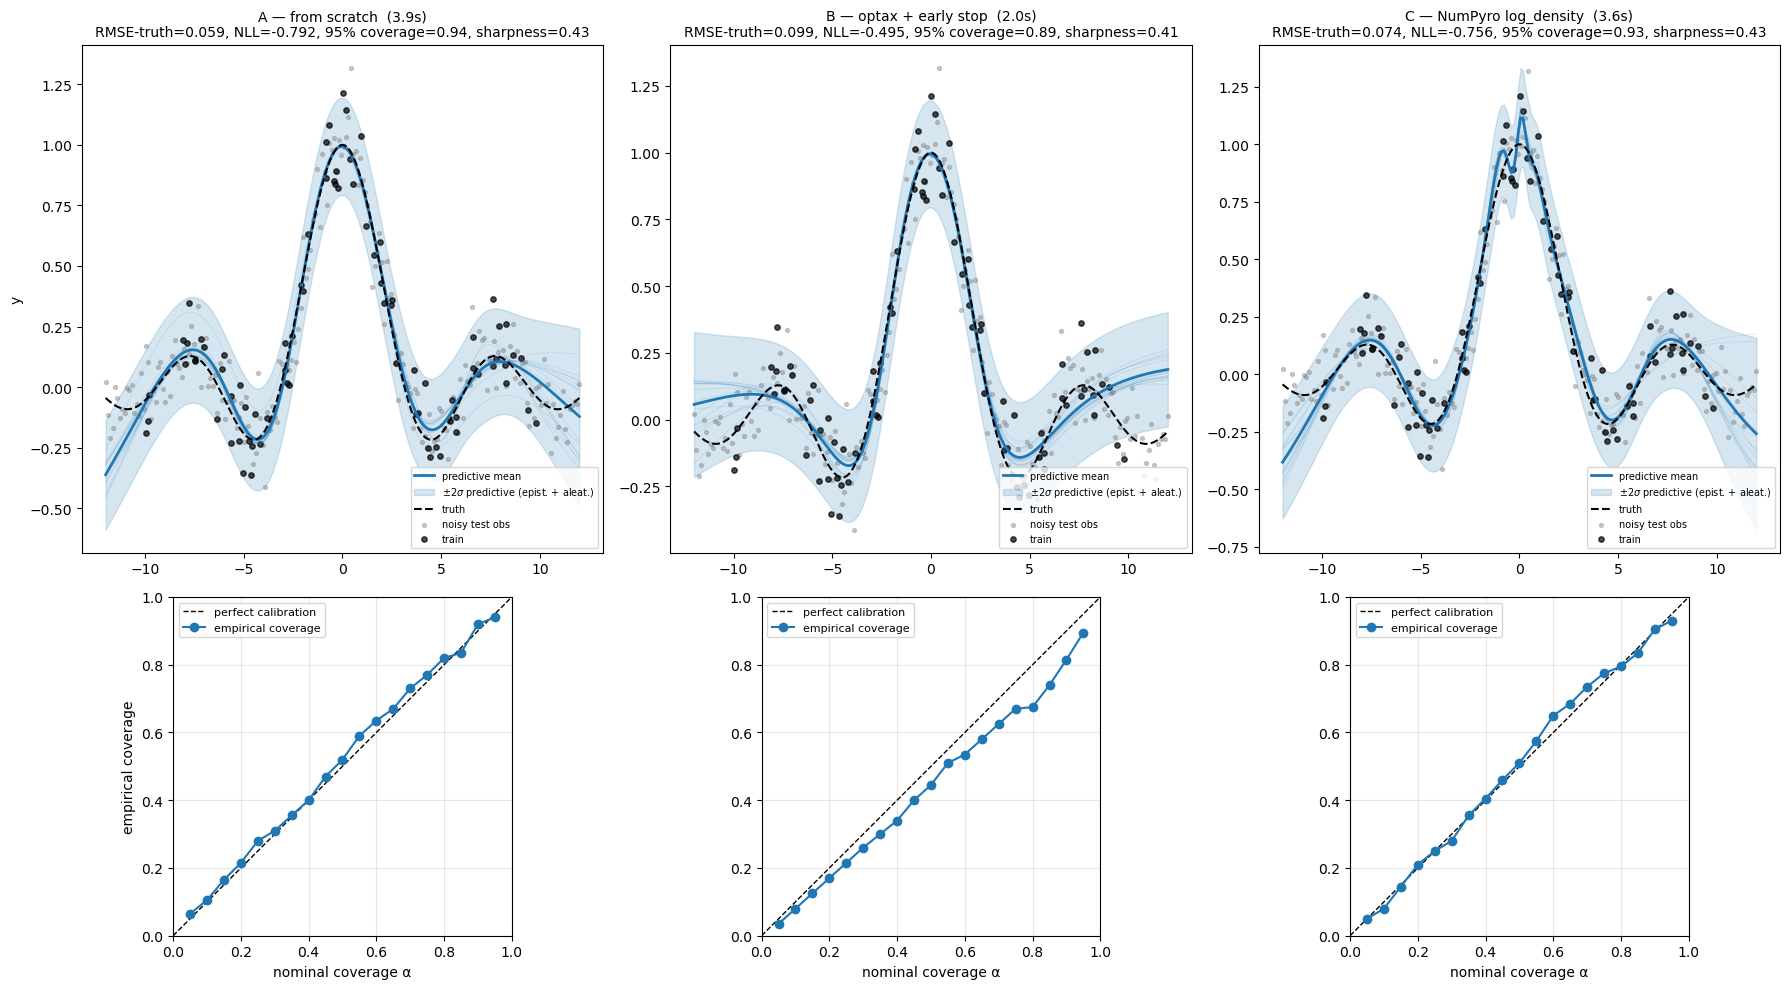

In [10]:
metrics_a = gof_metrics(preds_a, SIGMA, y_truth, y_test_noisy)
metrics_b = gof_metrics(preds_b, SIGMA, y_truth, y_test_noisy)
metrics_c = gof_metrics(preds_c, SIGMA, y_truth, y_test_noisy)

fig, axes = plt.subplots(
    2, 3, figsize=(18, 10), gridspec_kw={"height_ratios": [3, 2]}, sharex="row"
)
patterns = [
    ("A — from scratch", preds_a, dt_a, metrics_a),
    ("B — optax + early stop", preds_b, dt_b, metrics_b),
    ("C — NumPyro log_density", preds_c, dt_c, metrics_c),
]

for j, (label, preds, dt, m) in enumerate(patterns):
    mean, total_std = predictive_band(preds, SIGMA)
    ax_top = axes[0, j]
    for member in preds:
        ax_top.plot(X_test, member, color="C0", alpha=0.12, lw=0.7)
    ax_top.plot(X_test, mean, color="C0", lw=2, label="predictive mean")
    ax_top.fill_between(
        X_test,
        mean - 2 * total_std,
        mean + 2 * total_std,
        color="C0",
        alpha=0.18,
        label=r"$\pm 2\sigma$ predictive (epist. + aleat.)",
    )
    ax_top.plot(X_test, y_truth, "k--", lw=1.5, label="truth")
    ax_top.scatter(
        X_test, y_test_noisy, s=8, color="grey", alpha=0.4, label="noisy test obs"
    )
    ax_top.scatter(X, y, s=15, color="black", alpha=0.7, label="train")
    ax_top.set_title(
        f"{label}  ({dt:.1f}s)\n"
        f"RMSE-truth={m['rmse_truth']:.3f}, NLL={m['nll']:.3f}, "
        f"95% coverage={m['coverage_95']:.2f}, sharpness={m['sharpness_95']:.2f}",
        fontsize=10,
    )
    if j == 0:
        ax_top.set_ylabel("y")
    ax_top.legend(loc="lower right", fontsize=7)

    ax_bot = axes[1, j]
    ax_bot.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
    ax_bot.plot(
        m["alphas"], m["coverage_curve"], "o-", color="C0", label="empirical coverage"
    )
    ax_bot.set_xlabel("nominal coverage α")
    if j == 0:
        ax_bot.set_ylabel("empirical coverage")
    ax_bot.set_xlim(0, 1)
    ax_bot.set_ylim(0, 1)
    ax_bot.set_aspect("equal")
    ax_bot.grid(alpha=0.3)
    ax_bot.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

### Summary table

- **RMSE-truth** — root mean squared error of the predictive mean against the noiseless truth. Pure accuracy of $\bar f$.
- **RMSE-obs** — root mean squared error against the noisy observations. Floor is $\sigma = 0.1$ (the irreducible noise).
- **NLL** — negative log predictive density of the noisy test observations under the mixture-of-Gaussians predictive. Lower is better. The oracle predictor (perfect $f$, known $\sigma$) gets NLL $= \tfrac{1}{2}\log(2\pi\sigma^2) + \tfrac{1}{2} \approx -0.88$.
- **95% coverage** — fraction of noisy test points inside the central 95% predictive interval. Calibrated $\Rightarrow$ 0.95.
- **Sharpness@95** — mean width of the central 95% predictive interval. Lower is better *given calibration*. With $\sigma = 0.1$, an oracle predictor's 95% interval has width $\approx 4\sigma = 0.4$.

In [11]:
oracle_nll = float(0.5 * jnp.log(2 * jnp.pi * SIGMA**2) + 0.5)
print(f"oracle NLL (perfect f, known σ): {oracle_nll:.3f}")
print(f"oracle 95% interval width (4σ): {4 * SIGMA:.2f}")
print()
print(
    f"{'Pattern':<35} {'Runtime':>8} {'RMSE-truth':>11} {'RMSE-obs':>9} {'NLL':>8} {'cov95':>7} {'sharp95':>9}"
)
for label, _, dt, m in patterns:
    print(
        f"{label:<35} {dt:>7.2f}s {m['rmse_truth']:>11.4f} {m['rmse_obs']:>9.4f} "
        f"{m['nll']:>8.3f} {m['coverage_95']:>7.2f} {m['sharpness_95']:>9.3f}"
    )

oracle NLL (perfect f, known σ): -0.884
oracle 95% interval width (4σ): 0.40

Pattern                              Runtime  RMSE-truth  RMSE-obs      NLL   cov95   sharp95
A — from scratch                       3.90s      0.0589    0.1089   -0.792    0.94     0.426
B — optax + early stop                 2.03s      0.0990    0.1370   -0.495    0.89     0.409
C — NumPyro log_density                3.58s      0.0745    0.1138   -0.756    0.93     0.431


## Takeaways

- **The primitives are minimal but composable.** `ensemble_init` + `ensemble_step` is the entire mandatory surface; everything else (the optimizer, the loop, the log-joint origin) is your decision.
- **Pattern A** is the right starting point when you want to understand exactly what's happening. No optax magic, no NumPyro, no schedules.
- **Pattern B** unlocks anything that needs Python control flow: early stopping, adaptive schedules, callbacks for logging or visualization, custom batching strategies. The price is that you can't `lax.scan` over a Python `if`/`break`, so you trade some speed for control.
- **Pattern C** is the bridge to existing NumPyro models. Anything you can express as a `numpyro` model plays nicely with the primitives via `log_density`. This is also how you'd run NUTS *and* an ensemble MAP on the same model — write the model once, point both inference paths at it.
- **All three are point-mass MAP ensembles.** Their predictive variance is $\mathrm{Var}_{\text{epist}} + \sigma^2$, where the epistemic term is typically much smaller than $\sigma^2$ inside the training range — so the bands are dominated by aleatoric noise there. In extrapolation regions ($|x| > 10$) the epistemic term grows, but only modestly, because all members were initialized in similar basins. To get *true* posterior-predictive uncertainty (especially in extrapolation), see the [runner tutorial](./ensemble_runner_tutorial.ipynb)'s `EnsembleVI` example.
- **When to step up:** if you don't need any of the manual-loop superpowers, the higher-level [`EnsembleMAP` runner](./ensemble_runner_tutorial.ipynb) is faster (it `lax.scan`s the loop) and shorter to write.